In [ ]:
import logging

import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib widget

fastf1.logger.set_log_level(logging.ERROR)
fastf1.plotting.setup_mpl(mpl_timedelta_support=False, color_scheme="fastf1")

In [2]:
race = fastf1.get_session(2025, 23, "R")
race.load()
laps = race.laps.pick_quicklaps()

In [3]:
transformed_laps = laps.copy()
transformed_laps.loc[:, "LapTime (s)"] = laps.LapTime.dt.total_seconds()

# Order the team from the fastest (lowest median lap time) to slower
team_order = (
    transformed_laps[["Driver", "LapTime (s)"]]
    .groupby("Driver")
    .median()["LapTime (s)"]
    .sort_values()
    .index
)

In [4]:
driver_team_dict = transformed_laps.set_index("Driver")["Team"].to_dict()

In [5]:
driver_palette = {
    driver: fastf1.plotting.get_team_color(team, session=race)
    for driver, team in driver_team_dict.items()
}

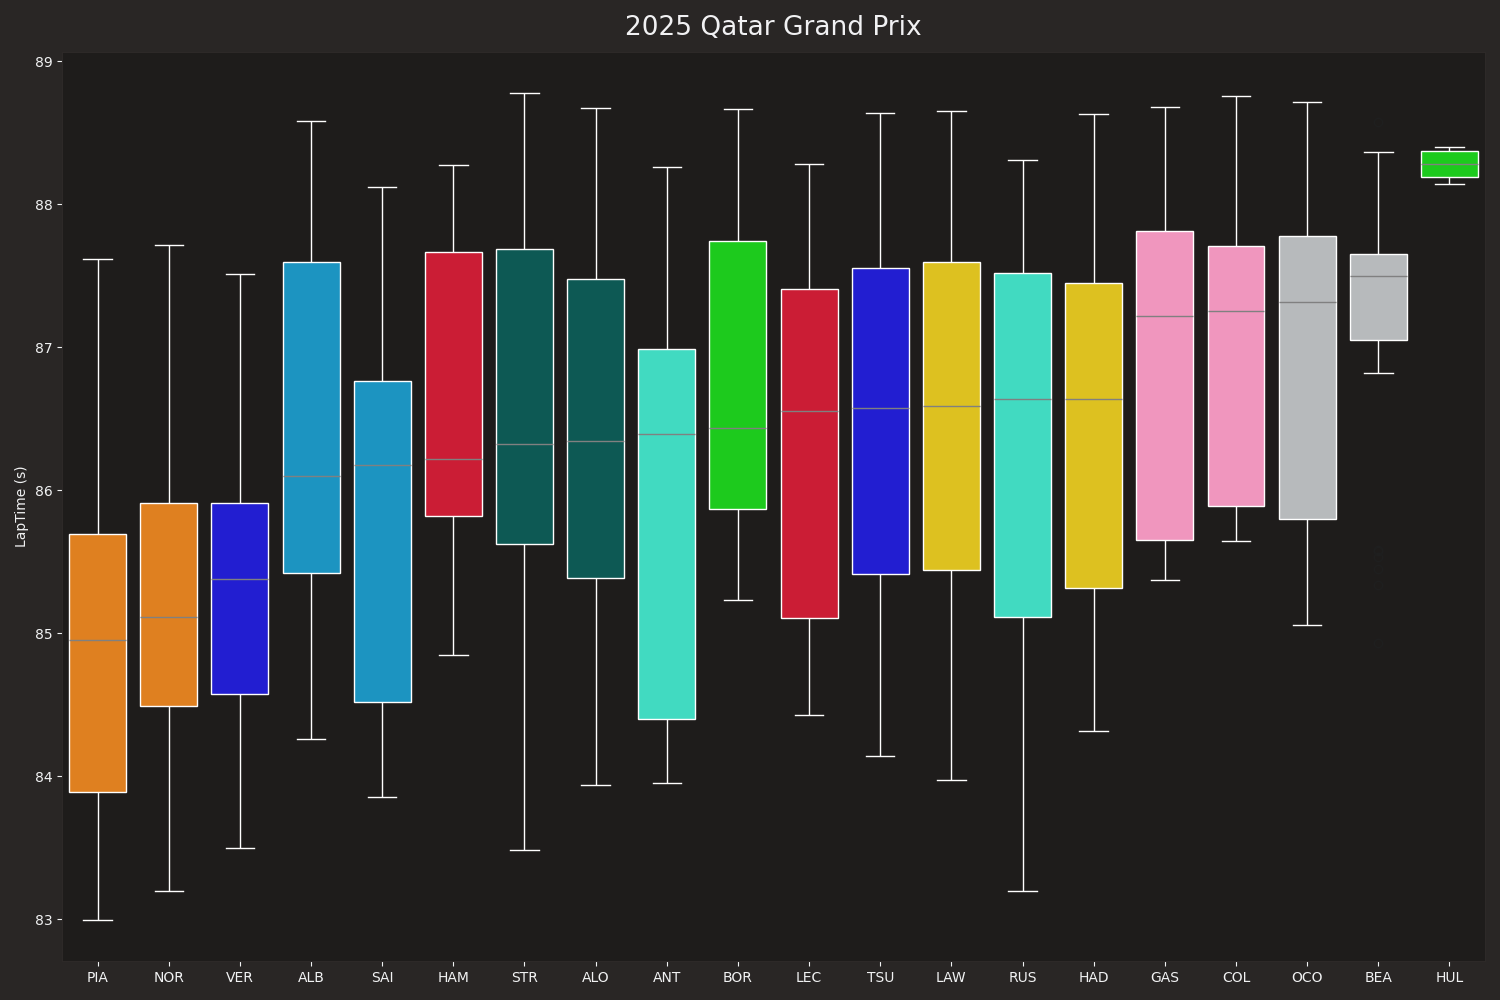

In [6]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.boxplot(
    data=transformed_laps,
    x="Driver",
    y="LapTime (s)",
    hue="Driver",
    order=team_order,
    palette=driver_palette,
    whiskerprops={"color": "white"},
    boxprops={"edgecolor": "white"},
    medianprops={"color": "grey"},
    capprops={"color": "white"},
)

plt.title("2025 Qatar Grand Prix")
plt.grid(visible=False)

ax.set(xlabel=None)
plt.tight_layout()
plt.show()

In [ ]:
laps = race.laps.pick_quicklaps()
transformed_laps = laps.copy()
transformed_laps.loc[:, "LapTime (s)"] = laps.LapTime.dt.total_seconds()

# Order the team from the fastest (lowest median lap time) to slowers
team_order = (
    transformed_laps[["Team", "LapTime (s)"]]
    .groupby("Team")
    .median()["LapTime (s)"]
    .sort_values()
    .index
)

In [8]:
team_palette = {team: fastf1.plotting.get_team_color(team, session=race)
                for team in team_order}

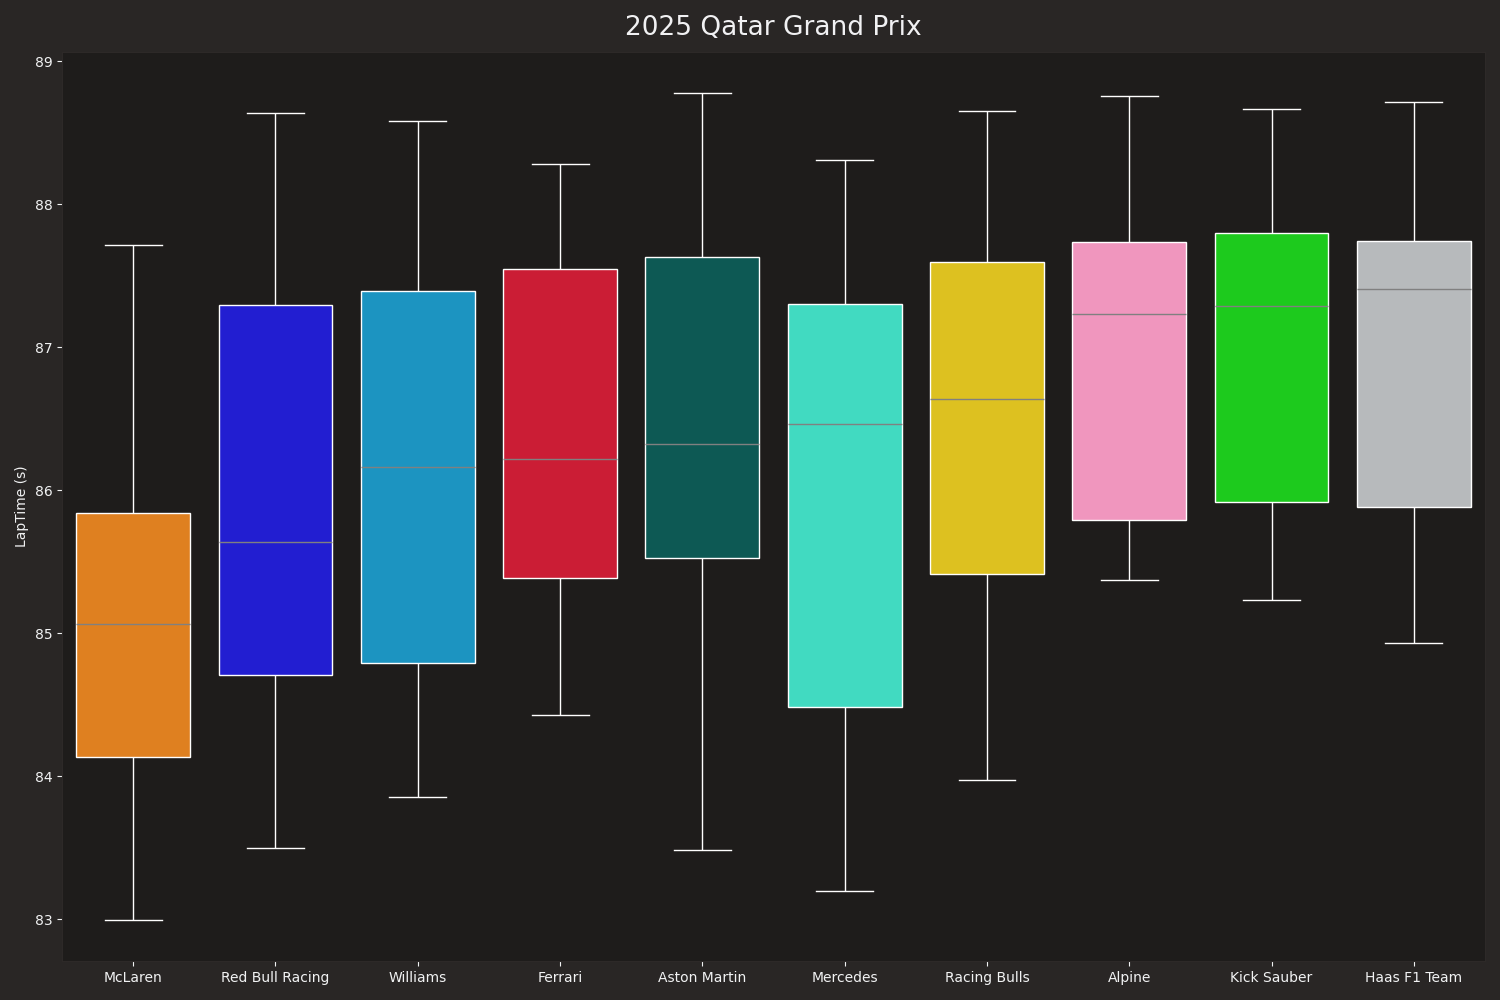

In [11]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.boxplot(
    data=transformed_laps,
    x="Team",
    y="LapTime (s)",
    hue="Team",
    order=team_order,
    palette=team_palette,
    whiskerprops={"color": "white"},
    boxprops={"edgecolor": "white"},
    medianprops={"color": "grey"},
    capprops={"color": "white"},
)

plt.title("2025 Qatar Grand Prix")
plt.grid(visible=False)

ax.set(xlabel=None)
plt.tight_layout()
plt.show()